In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  

proxy = 'http://10.20.38.38:7890'
os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy
import sys
sys.path.append('/home/ldy/Closed_loop_optimizing/model')
import torch
from PIL import Image
from torchvision import transforms
import torchvision.models as models
import torch.nn as nn
from einops.layers.torch import Rearrange
import math
import importlib
# import util
# importlib.reload(util)
import json
import open_clip
import torch.nn.functional as F
from torch.utils.data import DataLoader
import random
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [2]:
model_type = 'ViT-H-14'     
vlmodel, preprocess_train, feature_extractor = open_clip.create_model_and_transforms(
    model_type, pretrained='laion2b_s32b_b79k', precision='fp32', device=device)

In [3]:
import numpy as np

# 指定根目录
# # feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/gaoyiou_female_1/rating'
# # feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/gaoyiou_female_2/rating'
# # feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/luweibin_male_1/rating'
# # feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/luweibin_male_2/rating'
# feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/mingjie_female_1/rating'
# feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/mingjie_female_2/rating'
# # feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/shenyuyang_male_1/rating'
# # feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/shenyuyang_male_2/rating'
# feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/suyu_male_1/rating'
# feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/suyu_male_2/rating'
# # feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/yichen_male_1/rating'
# # feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/yichen_male_2/rating'
# feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/yiming_male_1/rating'
# feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/yiming_male_2/rating'
feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/yuanjiamu_female_1/rating'
# feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/yuanjiamu_female_2/rating'
# feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/zhaoquanbo_male_1/rating'
# feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/zhaoquanbo_male_2/rating'
# feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/zhouyijun_female_1/rating'
# feature_directory = '/home/ldy/Closed_loop_optimizing/server/outputs/zhouyijun_female_2/rating'

# 收集所有JSON文件中的列表内容
ratings = np.load(os.path.join(feature_directory, "all_viewed_image_ratings.npy"), allow_pickle=True)

# 打印结果或进行其他处理
print(f"总共收集了 {len(ratings)} 个ratings")

总共收集了 64 个ratings


In [4]:
ratings

array([0.65, 0.7, 0.2, 0.1, 0.5, 0.44, 0.76, 0.81, 0.62, 0.85, 0.88, 0.76,
       0.17, 0.64, 0.5, 0.2, 0.89, 0.49, 0.81, 0.65, 0.34, 0.5, 0.52,
       0.67, 0.63, 0.57, 0.89, 0.91, 0.5, 0.84, 0.34, 0.63, 0.72, 0.52,
       0.57, 0.56, 0.32, 0.5, 0.9, 0.77, 0.59, 0.8, 0.86, 0.92, 0.62,
       0.68, 0.56, 0.56, 0.32, 0.66, 0.32, 0.09, 0.6, 0.6, 0.7, 0.25,
       0.21, 0.54, 0.7, 0.75, 0.45, 0.45, 0.5, 0.4], dtype=object)

In [5]:
images_paths = np.load(os.path.join(feature_directory, "viewed_image_paths.npy"), allow_pickle=True)
images_paths

array(['image_pool_square/square_Amu-10.jpg',
       'image_pool_square/square_Amu-14.jpg',
       'image_pool_square/square_Dis-02.jpg',
       'image_pool_square/square_Dis-05.jpg',
       'image_pool_square/square_Fea-04.jpg',
       'image_pool_square/square_Fea-05.jpg',
       'image_pool_square/square_Ten-04.jpg',
       'image_pool_square/square_Ten-07.jpg',
       'image_pool_square/square_amusement_03820.jpg',
       'image_pool_square/square_awe_00360.jpg',
       'server/outputs/yuanjiamu_female_1/rating/loop2/fusion/generated_0.jpg',
       'server/outputs/yuanjiamu_female_1/rating/loop2/fusion/generated_1.jpg',
       'server/outputs/yuanjiamu_female_1/rating/loop2/greedy/greedy_0.jpg',
       'server/outputs/yuanjiamu_female_1/rating/loop2/greedy/greedy_1.jpg',
       'server/outputs/yuanjiamu_female_1/rating/loop2/greedy/greedy_2.jpg',
       'server/outputs/yuanjiamu_female_1/rating/loop2/greedy/greedy_3.jpg',
       'server/outputs/yuanjiamu_female_1/rating/loop3/fusio

In [6]:
# images_paths = [path.replace("yiming", "yiming_male_2") for path in images_paths]


In [7]:
images_paths

array(['image_pool_square/square_Amu-10.jpg',
       'image_pool_square/square_Amu-14.jpg',
       'image_pool_square/square_Dis-02.jpg',
       'image_pool_square/square_Dis-05.jpg',
       'image_pool_square/square_Fea-04.jpg',
       'image_pool_square/square_Fea-05.jpg',
       'image_pool_square/square_Ten-04.jpg',
       'image_pool_square/square_Ten-07.jpg',
       'image_pool_square/square_amusement_03820.jpg',
       'image_pool_square/square_awe_00360.jpg',
       'server/outputs/yuanjiamu_female_1/rating/loop2/fusion/generated_0.jpg',
       'server/outputs/yuanjiamu_female_1/rating/loop2/fusion/generated_1.jpg',
       'server/outputs/yuanjiamu_female_1/rating/loop2/greedy/greedy_0.jpg',
       'server/outputs/yuanjiamu_female_1/rating/loop2/greedy/greedy_1.jpg',
       'server/outputs/yuanjiamu_female_1/rating/loop2/greedy/greedy_2.jpg',
       'server/outputs/yuanjiamu_female_1/rating/loop2/greedy/greedy_3.jpg',
       'server/outputs/yuanjiamu_female_1/rating/loop3/fusio

In [8]:
from tqdm import tqdm    
def ImageEncoder(images):
    batch_size = 4   
    image_features_list = []
    
    # for i in range(0, len(images), batch_size):
    for i in tqdm(range(0, len(images), batch_size), leave=False):
        batch_images = images[i:i + batch_size]
        image_inputs = torch.stack([preprocess_train(Image.open(os.path.join("/home/ldy/Closed_loop_optimizing",img)).convert("RGB")) for img in batch_images])

        with torch.no_grad():
            batch_image_features = vlmodel.encode_image(image_inputs.to(device))
        image_features_list.append(batch_image_features)
        del batch_images

    image_features = torch.cat(image_features_list, dim=0)                        
    return image_features    

latents = ImageEncoder(images_paths)       

In [9]:
latents.shape

torch.Size([64, 1024])

In [10]:
latents[:32].shape

torch.Size([32, 1024])

In [11]:

# Initialize lists to store the data
data_x_list = []
data_y_list = []

for i, img_embed in enumerate(latents[:32]):
    # Append the current data to the lists
    data_x_list.append(img_embed)
    data_y_list.append(-ratings[i] *100.0)

# Convert lists to tensors and create the data dictionary
data = {
    "data_x": torch.stack(data_x_list),  # Stack image embeddings to form a batch
    "data_y": torch.tensor(data_y_list)  # Convert similarities to tensor
}



In [12]:
import os
import torch

output_base_dir = "/home/ldy/Closed_loop_optimizing/Heuristic_generation/human-exps"

# Find the next available exp directory
exp_num = 0
while True:
    exp_dir = os.path.join(output_base_dir, f"exp{exp_num+1}")
    if not os.path.exists(exp_dir):
        break
    exp_num += 1

# Create the new exp directory
os.makedirs(exp_dir, exist_ok=True)

# Save the data to data.pth in the new directory
torch.save(data, os.path.join(exp_dir, "rating_data_scaling.pth"))

print(f"Data saved to {exp_dir}")

Data saved to /home/ldy/Closed_loop_optimizing/Heuristic_generation/human-exps/exp67


In [13]:
from diffusers.utils import load_image
from IPython.display import display
import sys
sys.path.append('/home/ldy/Closed_loop_optimizing')
sys.path.append('/home/ldy/Closed_loop_optimizing/model')
from model.custom_pipeline_low_level import Generator4Embeds
from transformers import CLIPVisionModelWithProjection, CLIPImageProcessor
import torch

from model.ATMS_retrieval import ATMS, get_eeg_features
from PIL import Image
import torchvision.transforms as transforms
import numpy as np
from util import save_eeg, get_gteeg
import open_clip
import einops
# from rewards import GeminiQuestion
from diffusers import AutoencoderKL, DDIMScheduler, UNet2DConditionModel
# from extended_diffusers import ExtendedStableDiffusionXLPipeline
from pseudo_target_model import PseudoTargetModel
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/ldy/Closed_loop_optimizing/model/eegdatasets_leaveone.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`

In [14]:
pipe = Generator4Embeds(device=device)
pipe = pipe.pipe


###################### hyper-paramters ######################
batch_size = 32
alpha = 80
total_steps = 30
max_inner_steps = 10
num_inference_steps = 8
guidance_scale = 0.0
# dimension = pipe.unet.config.in_channels * pipe.unet.config.sample_size * pipe.unet.config.sample_size
dimension = 1024
self_improvement_ratio = 0.5
reward_scaling_factor = 100
initial_step_size = 30
decay_rate = 0.1  # 调整衰减率
###################### hyper-paramters ######################
is_train = False
# prompt = 'A yellow reindeer and a blue elephant.'
prompt = ''
########################### utils ###########################
@torch.inference_mode()
def latents_to_images(latents):
    shift_factor = pipe.vae.config.shift_factor if pipe.vae.config.shift_factor else 0.0
    latents = (latents / pipe.vae.config.scaling_factor) + shift_factor
    images = pipe.vae.decode(latents, return_dict=False)[0]
    images = pipe.image_processor.postprocess(images)
    return images

def x_flatten(x):
    return einops.rearrange(x, '... C W H -> ... (C W H)', C=pipe.unet.config.in_channels, W=pipe.unet.config.sample_size, H=pipe.unet.config.sample_size)
def x_unflatten(x):
    return einops.rearrange(x, '... (C W H) -> ... C W H', C=pipe.unet.config.in_channels, W=pipe.unet.config.sample_size, H=pipe.unet.config.sample_size)
def get_norm(epsilon):
    return x_flatten(epsilon).norm(dim=-1)[:,:,None,None,None]
def merge_images_grid(image_grid):
    # Assuming image_grid is a 2D list: [[img00, img01, ...], [img10, img11, ...], ...]
    rows = len(image_grid)
    cols = len(image_grid[0])

    # Assume all images are the same size
    img_width, img_height = image_grid[0][0].size

    # Create a new blank image with correct total size
    merged_image = Image.new('RGB', (cols * img_width, rows * img_height))

    for row_idx, row in enumerate(image_grid):
        for col_idx, img in enumerate(row):
            merged_image.paste(img, (col_idx * img_width, row_idx * img_height))

    return merged_image

generator = torch.Generator(device="cuda").manual_seed(0)
########################### utils ###########################


pseudo_target_model = PseudoTargetModel(dimension=dimension, noise_level=1e-4)
pseudo_target_model = pseudo_target_model.to("cuda")

generate_batch_size = 3
save_per = 5
data = torch.load(os.path.join(exp_dir, "rating_data_scaling.pth"))
data_x, data_y = data["data_x"].to(device), data["data_y"].to(device)


# pseudo_target_model.add_model_data(x_flatten(data_x), data_y)
pseudo_target_model.add_model_data(data_x, data_y)

epsilon = torch.randn(num_inference_steps+1, generate_batch_size, pipe.unet.config.in_channels, pipe.unet.config.sample_size, pipe.unet.config.sample_size, device="cuda", generator=generator)


epsilon_init = epsilon.clone()
epsilon_init_norm = get_norm(epsilon_init)
all_images = []
# print(f"epsilon {epsilon[1:].shape}")
# pipe.load_ip_adapter(
#     "h94/IP-Adapter", subfolder="sdxl_models", 
#     weight_name="ip-adapter_sdxl_vit-h.bin", 
#     torch_dtype=torch.bfloat16)
# pipe.set_ip_adapter_scale(0.5)

# pseudo_target = torch.randn(num_inference_steps+1, generate_batch_size, 1024, device="cuda", generator=generator)
# pseudo_target = torch.randn(generate_batch_size, 1024, device="cuda", generator=generator)


y_preds = []
for latent in latents[32:]:             
    pseudo_target, y_pred = pseudo_target_model.estimate_pseudo_target(latent.unsqueeze(0), step_size=20)        
    y_preds.append(y_pred)    
        
    # if step % save_per == 0:
    #     print(f"scaled_similarity {scaled_similarity}")
    #     all_images.append(images)


Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  8.67it/s]
/tmp/ipykernel_2814734/3055676540.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = t

In [15]:
y_preds

[tensor([[-56.3343]], device='cuda:0'),
 tensor([[-50.1437]], device='cuda:0'),
 tensor([[-61.1883]], device='cuda:0'),
 tensor([[-64.4215]], device='cuda:0'),
 tensor([[-45.2100]], device='cuda:0'),
 tensor([[-54.4630]], device='cuda:0'),
 tensor([[-81.3337]], device='cuda:0'),
 tensor([[-61.5542]], device='cuda:0'),
 tensor([[-63.7207]], device='cuda:0'),
 tensor([[-75.4376]], device='cuda:0'),
 tensor([[-63.9247]], device='cuda:0'),
 tensor([[-55.8998]], device='cuda:0'),
 tensor([[-59.3726]], device='cuda:0'),
 tensor([[-47.5891]], device='cuda:0'),
 tensor([[-66.0922]], device='cuda:0'),
 tensor([[-70.8879]], device='cuda:0'),
 tensor([[-30.6482]], device='cuda:0'),
 tensor([[-54.4288]], device='cuda:0'),
 tensor([[-50.0031]], device='cuda:0'),
 tensor([[-15.8814]], device='cuda:0'),
 tensor([[-70.0361]], device='cuda:0'),
 tensor([[-71.0614]], device='cuda:0'),
 tensor([[-60.5750]], device='cuda:0'),
 tensor([[-27.2770]], device='cuda:0'),
 tensor([[-57.4387]], device='cuda:0'),


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def plot_correlation_scatter_with_ci(x, y, xlabel="Participant to RTNet", ylabel="Participant to group", save_path=""):
    """
    绘制带置信区间的相关散点图
    
    参数:
    x, y -- 两个numpy数组
    xlabel, ylabel -- 坐标轴标签
    """
    
    # 计算Pearson相关系数和p值
    r, p = stats.pearsonr(x, y)
    
    # 创建图形
    plt.figure(figsize=(6, 5.5), dpi=300)
    
    # 设置颜色
    point_color = '#1f77b4'  # 散点颜色
    line_color = '#1f77b4'   # 回归线颜色 (与散点相同)
    ci_color = '#8ab4d6'     # 更浅的蓝色用于置信区间
    
    # 绘制散点图 (增加透明度)
    plt.scatter(x, y, color=point_color, s=150, alpha=0.6, edgecolors='none')
    
    # 设置坐标轴标签
    plt.xlabel(xlabel, fontsize=22, fontfamily='sans-serif', labelpad=10)
    plt.ylabel(ylabel, fontsize=22, fontfamily='sans-serif', labelpad=10)
    
    # # 设置标题
    # plt.title("Accuracy", fontsize=14, fontfamily='sans-serif', pad=20, 
    #           fontweight='normal', loc='center')
    
    # 计算回归线和置信区间
    slope, intercept = np.polyfit(x, y, 1)
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = slope * x_fit + intercept
    
    # 计算预测值的标准误差和置信区间
    y_err = y - (slope * x + intercept)
    x_mean = np.mean(x)
    n = len(x)
    stdev = np.sqrt(np.sum(y_err**2) / (n - 2))
    
    confidence = 0.95  # 95%置信区间
    t_val = stats.t.ppf((1 + confidence) / 2, n - 2)
    
    margin_of_error = t_val * stdev * np.sqrt(1/n + (x_fit - x_mean)**2 / np.sum((x - x_mean)**2))
    lower_bound = y_fit - margin_of_error
    upper_bound = y_fit + margin_of_error
    
    # 绘制置信区间 (使用更浅的蓝色)
    plt.fill_between(x_fit, lower_bound, upper_bound, color=ci_color, alpha=0.2)
    
    # 绘制回归线 (使用与散点相同的颜色)
    plt.plot(x_fit, y_fit, color=line_color, linewidth=3, alpha=0.8)
    
    # 添加统计信息
    stats_text = f"R = {r:.3f}\nP < 0.001" if p < 0.001 else f"R = {r:.3f}\nP = {p:.3f}"
    plt.text(0.98, 0.02, stats_text, transform=plt.gca().transAxes,
             fontsize=25, fontfamily='sans-serif',
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=4))
    
    # 调整坐标轴样式
    plt.tick_params(axis='both', which='major', labelsize=22)
    plt.grid(False)
    
    # 移除顶部和右侧边框
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)
    
    # 设置紧凑布局
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    
    return r, p

In [17]:
y_preds = torch.stack(y_preds)
y_preds = y_preds.squeeze(1).squeeze(1)
y_preds.shape

torch.Size([32])

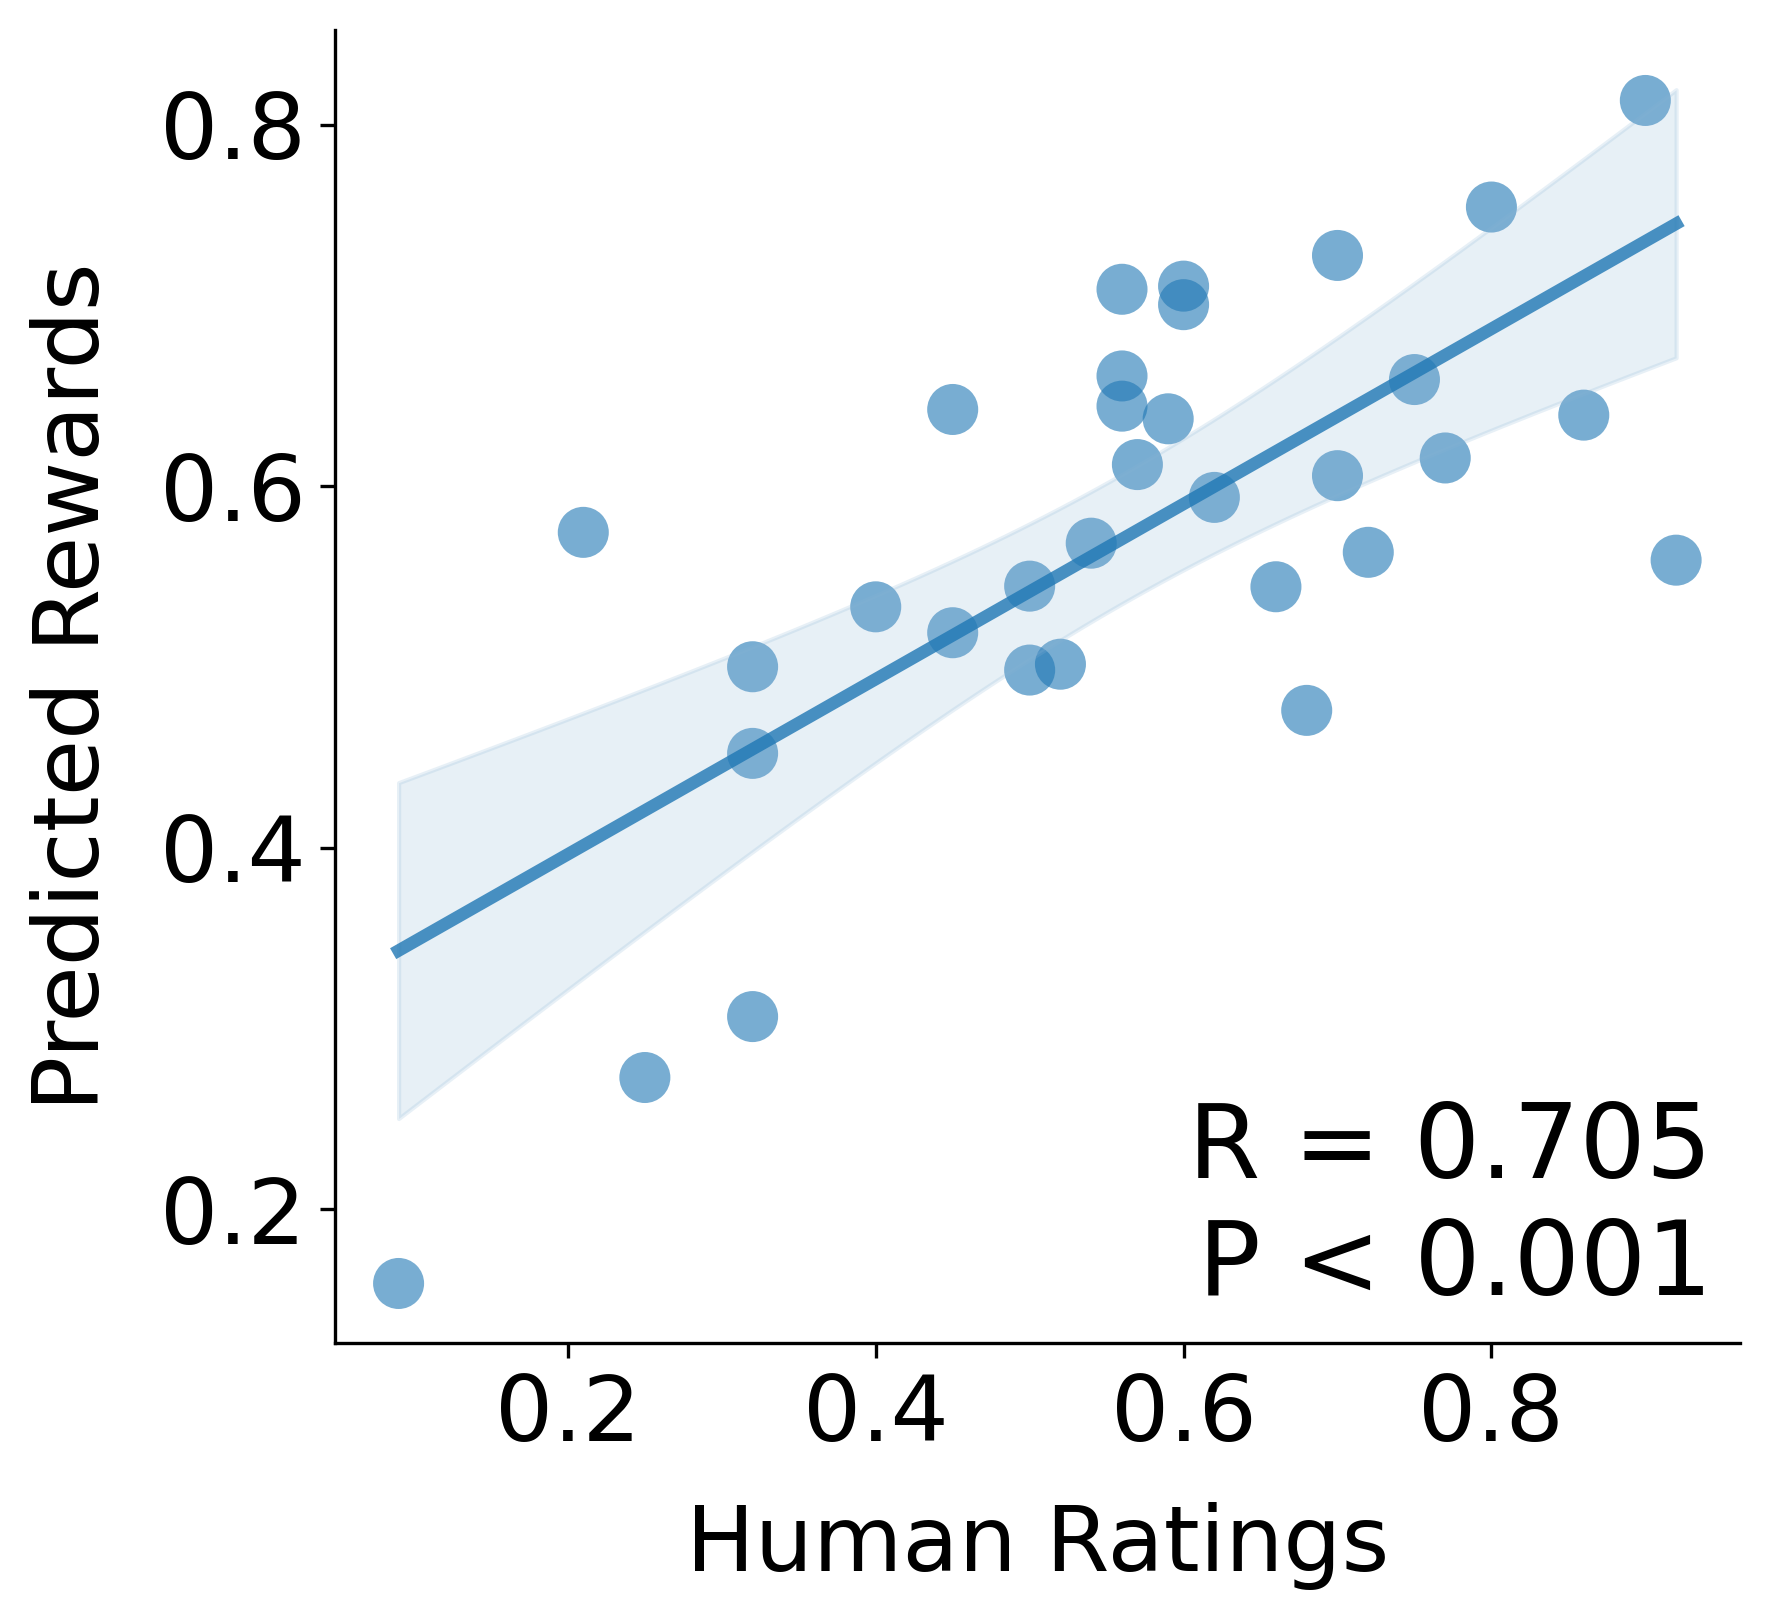

In [18]:
import numpy as np

# # 示例数据
# x = np.random.normal(0, 1, 100)
# y = x * 0.685 + np.random.normal(0, 0.5, 100)
ratings = np.array(ratings, dtype=np.float64)
y_preds = np.array(np.asarray(y_preds.cpu()), dtype=np.float64)
# 调用函数
r, p = plot_correlation_scatter_with_ci(ratings[32:], -y_preds/100, xlabel="Human Ratings", ylabel="Predicted Rewards", save_path="/home/ldy/Closed_loop_optimizing/Heuristic_generation/plots/emotion_rating_estimator_scatter.png")